In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import RFE, mutual_info_regression
from sklearn.decomposition import PCA
from math import sqrt
import os

results_list = []

def save_results(model_name, y_true, y_pred, author, method):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    results_list.append({
        'Geliştiren': author, 'Model': model_name, 'Metot': method, 
        'R2_Score': r2, 'MAE': mae, 'RMSE': rmse
    })
    print(f"✅ {author} - {model_name} kaydedildi.")

In [244]:
df = pd.read_excel('gold_data.xlsx')
df.columns = df.columns.str.strip()

# Tarih sütununu indeks yapma ve kontrol
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print("🚀 Date sütunu başarıyla indeks yapıldı.")
print("Güncel İndeks Tipi:", df.index.dtype)
print("\n--- İlk 5 Kayıt ---")
display(df.head())

# Eksik Değer Kontrolü
print("\n--- Eksik Değer Sayısı ---")
print(df.isnull().sum())

🚀 Date sütunu başarıyla indeks yapıldı.
Güncel İndeks Tipi: datetime64[ns]

--- İlk 5 Kayıt ---


,Open,High,Low,Close,Volume,USD_Index,Oil_Price,SP500,Inflation_Rate,Interest_Rate,Exchange_Rate,Silver_Price,Bitcoin_Price,Market_Sentiment,Global_Uncertainty,Gold_ETF_Holdings,Mining_Production,Demand_Index,Predicted_Close
Date,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,1561.810178,2450.057992,998.952029,1837.279514,630597,82.958541,93.286275,3385.795570,5.675399,0.357507,22.334318,18.985880,29801.404203,0.663784,95.560565,562.237919,528.688438,108.285872,2356.796937
2022-01-01 01:00:00,2426.071460,1607.806820,1897.256866,1527.707818,945060,92.464259,98.534174,2963.477591,6.071568,14.329028,33.343211,37.391994,9975.175458,-0.273577,54.535731,973.935428,624.911450,102.352777,1223.163083
2022-01-01 02:00:00,2097.990913,1734.993509,2410.043079,1131.575493,312580,95.306958,87.049872,2633.452643,0.944284,13.770735,25.240981,14.729793,44401.781618,-0.104183,57.364770,1159.182170,784.722089,57.966225,1597.666204
2022-01-01 03:00:00,1897.987726,1653.443168,2107.058378,1153.447534,722435,99.467653,71.931234,2223.525085,8.012654,2.177062,27.720166,38.640605,9011.559289,0.389160,96.776303,730.959599,447.331375,102.317642,2399.255405
2022-01-01 04:00:00,1234.027961,1434.847886,1331.613890,1282.767421,312212,96.263351,50.334322,2468.735231,5.957010,13.045183,10.420123,34.493588,44301.018924,0.926001,49.005010,870.233044,448.021198,96.929878,2250.660740



--- Eksik Değer Sayısı ---
Open                  0
High                  0
Low                   0
Close                 0
Volume                0
USD_Index             0
Oil_Price             0
SP500                 0
Inflation_Rate        0
Interest_Rate         0
Exchange_Rate         0
Silver_Price          0
Bitcoin_Price         0
Market_Sentiment      0
Global_Uncertainty    0
Gold_ETF_Holdings     0
Mining_Production     0
Demand_Index          0
Predicted_Close       0
dtype: int64


In [245]:
df = df.sort_index()

#Lag
for i in [24, 48, 72]:
    df[f'Lag_{i}h'] = df['Close'].shift(i)

#Rolling MA & Volatility
windows = {'1w': 7, '1m': 30, '2m': 60, '3m': 90, '6m': 180, '1y': 365}
for name, win in windows.items():
    df[f'MA_{name}'] = df['Close'].rolling(window=win).mean()
    df[f'Vol_{name}'] = df['Close'].rolling(window=win).std()

# NAN SATIRLARI TEMİZLEME
df.dropna(inplace=True)
print(f"✅ Özellik mühendisliği tamamlandı. Yeni veri boyutu: {df.shape}")

✅ Özellik mühendisliği tamamlandı. Yeni veri boyutu: (25916, 34)


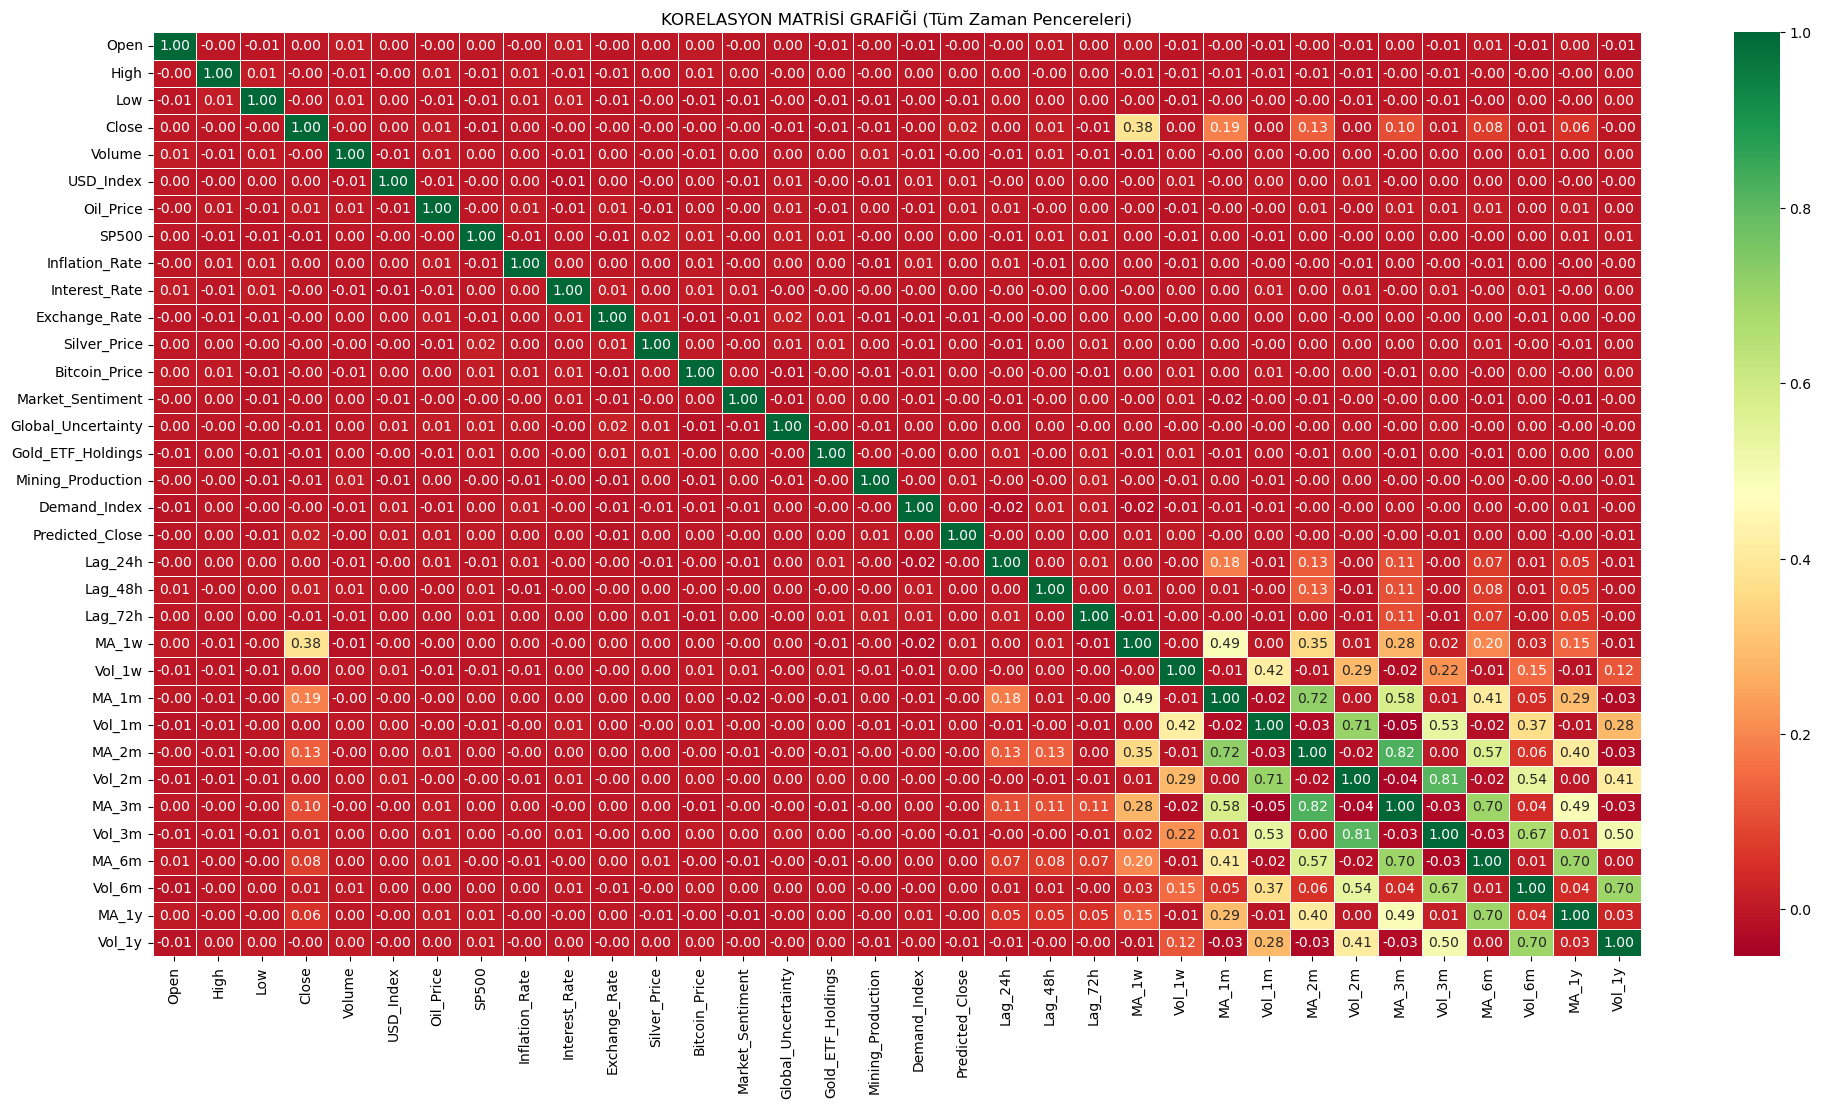

In [246]:
plt.figure(figsize=(24, 12))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('KORELASYON MATRİSİ GRAFİĞİ (Tüm Zaman Pencereleri)')
plt.show()

In [247]:
target = 'Predicted_Close'
X = df.drop(columns=[target])
y = df[target]

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [248]:
# HASAN ÖNDER SERT
rfe = RFE(LinearRegression(), n_features_to_select=10).fit(X_train_scaled, y_train)
X_tr_rfe, X_ts_rfe = rfe.transform(X_train_scaled), rfe.transform(X_test_scaled)
save_results("Lasso", y_test, Lasso(alpha=0.01).fit(X_tr_rfe, y_train).predict(X_ts_rfe), "Hasan Önder", "RFE")
save_results("KNN", y_test, KNeighborsRegressor(n_neighbors=5).fit(X_tr_rfe, y_train).predict(X_ts_rfe), "Hasan Önder", "RFE")

# ORHAN ARSLAN
pca = PCA(n_components=10).fit(X_train_scaled)
X_tr_pca, X_ts_pca = pca.transform(X_train_scaled), pca.transform(X_test_scaled)
save_results("Ridge", y_test, Ridge().fit(X_tr_pca, y_train).predict(X_ts_pca), "Orhan Arslan", "PCA")
save_results("SVR", y_test, SVR().fit(X_tr_pca, y_train).predict(X_ts_pca), "Orhan Arslan", "PCA")

# ASFANDIYOR FARKHADOV
top_corr = df.corr()[target].sort_values(ascending=False).index[1:11]
save_results("Linear Regression", y_test, LinearRegression().fit(X_train_scaled[top_corr], y_train).predict(X_test_scaled[top_corr]), "Asfandiyor", "Correlation")
save_results("Decision Tree", y_test, DecisionTreeRegressor().fit(X_train_scaled[top_corr], y_train).predict(X_test_scaled[top_corr]), "Asfandiyor", "Correlation")

# KUTAY KUBİLAY KAYHAN
mi = mutual_info_regression(X_train_scaled, y_train)
mi_cols = X_train_scaled.columns[np.argsort(mi)[-10:]]
save_results("ElasticNet", y_test, ElasticNet().fit(X_train_scaled[mi_cols], y_train).predict(X_test_scaled[mi_cols]), "Kutay Kubilay", "Mutual Info")
save_results("Bayesian Ridge", y_test, BayesianRidge().fit(X_train_scaled[mi_cols], y_train).predict(X_test_scaled[mi_cols]), "Kutay Kubilay", "Mutual Info")

✅ Hasan Önder - Lasso kaydedildi.
✅ Hasan Önder - KNN kaydedildi.
✅ Orhan Arslan - Ridge kaydedildi.
✅ Orhan Arslan - SVR kaydedildi.
✅ Asfandiyor - Linear Regression kaydedildi.
✅ Asfandiyor - Decision Tree kaydedildi.
✅ Kutay Kubilay - ElasticNet kaydedildi.
✅ Kutay Kubilay - Bayesian Ridge kaydedildi.


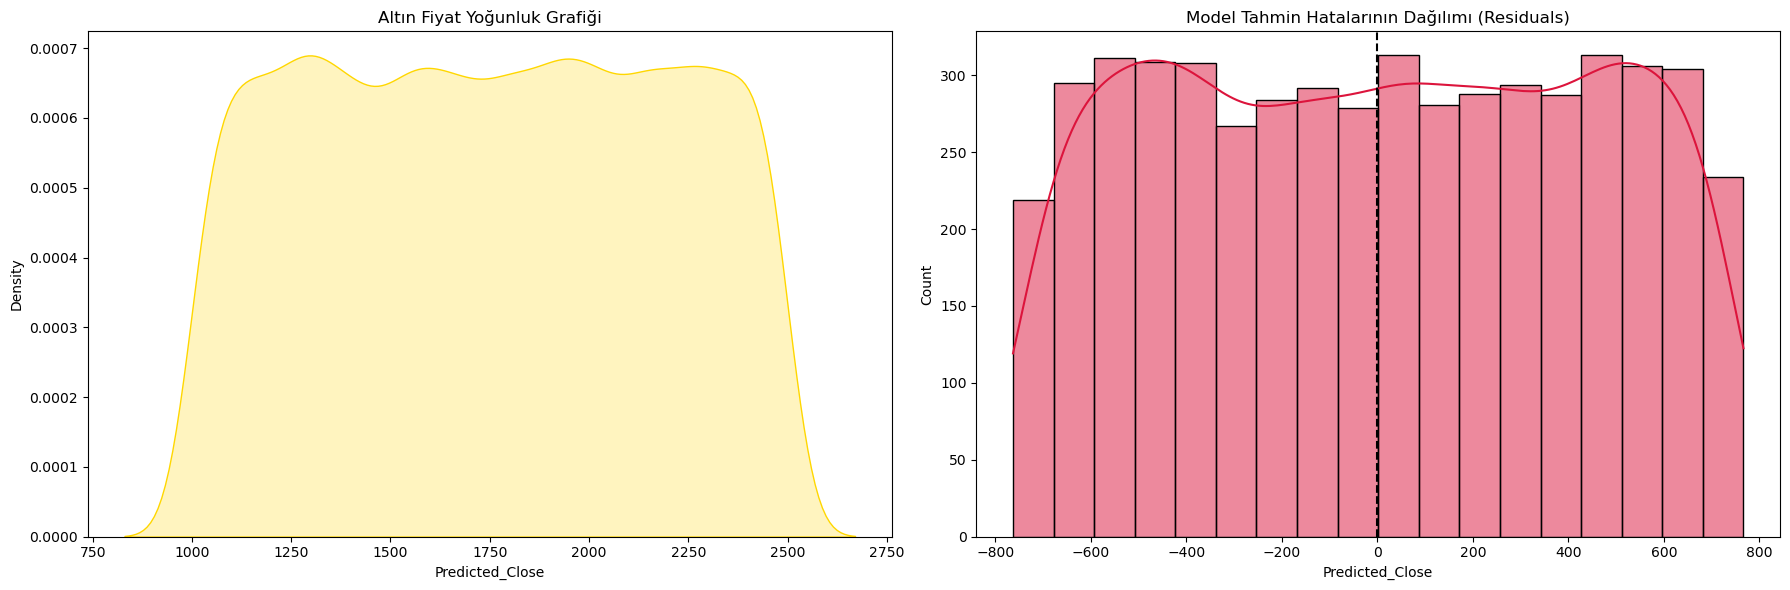

In [249]:
plt.figure(figsize=(18, 6))


plt.subplot(1, 2, 1)
sns.kdeplot(df[target], fill=True, color="gold")
plt.title('Altın Fiyat Yoğunluk Grafiği')


plt.subplot(1, 2, 2)
y_pred_final = Ridge().fit(X_tr_pca, y_train).predict(X_ts_pca)
residuals = y_test - y_pred_final
sns.histplot(residuals, kde=True, color="crimson")
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Model Tahmin Hatalarının Dağılımı (Residuals)')

plt.tight_layout()
plt.show()

In [250]:
comp_df = pd.DataFrame(results_list).sort_values('R2_Score', ascending=False)
display(comp_df)

,Geliştiren,Model,Metot,R2_Score,MAE,RMSE
7,Kutay Kubilay,Bayesian Ridge,Mutual Info,-0.000110,376.651150,433.765268
6,Kutay Kubilay,ElasticNet,Mutual Info,-0.000423,376.735351,433.833141
3,Orhan Arslan,SVR,PCA,-0.000471,376.786033,433.843485
4,Asfandiyor,Linear Regression,Correlation,-0.000626,376.772833,433.877165
2,Orhan Arslan,Ridge,PCA,-0.000681,376.743142,433.889173
0,Hasan Önder,Lasso,RFE,-0.002399,377.154821,434.261400
1,Hasan Önder,KNN,RFE,-0.199184,399.902140,474.978359
5,Asfandiyor,Decision Tree,Correlation,-1.026119,505.068960,617.395462


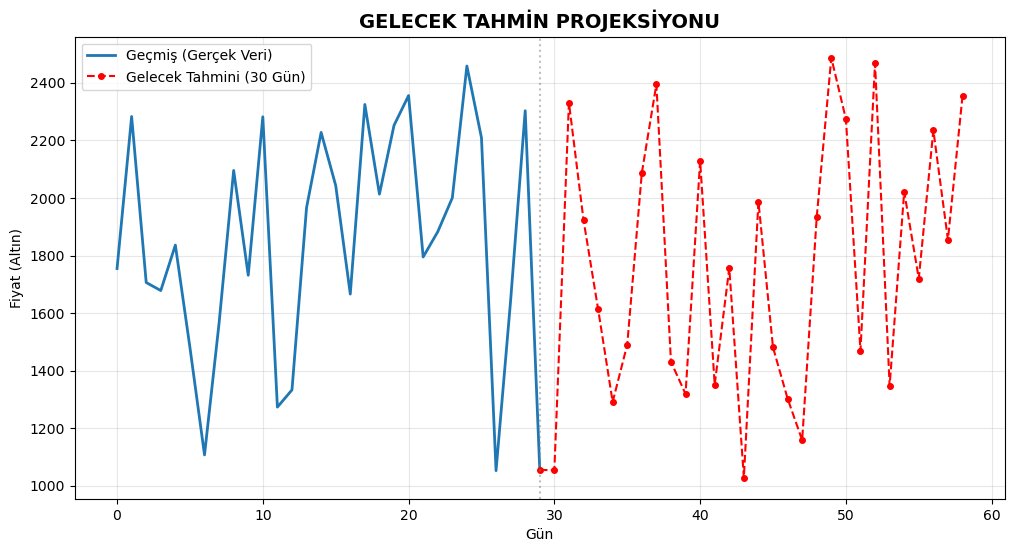

Tahmin edilen ilk 5 gün:
1. Gün: 1054.56
2. Gün: 2331.13
3. Gün: 1923.64
4. Gün: 1614.17
5. Gün: 1291.21


In [251]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


beklenen_sutunlar = scaler.feature_names_in_


X_final = df[beklenen_sutunlar]
y_final = df['Close']

tahmin_modeli = LinearRegression()

X_transformed = scaler.transform(X_final)
tahmin_modeli.fit(X_transformed, y_final)


gun_sayisi = 30 

last_row_raw = df[beklenen_sutunlar].iloc[-1:].values
current_step = scaler.transform(pd.DataFrame(last_row_raw, columns=beklenen_sutunlar))

future_predictions = []
temp_step = current_step.copy()


for i in range(gun_sayisi):

    next_pred = tahmin_modeli.predict(temp_step)[0]
    future_predictions.append(next_pred)

    temp_step = np.roll(temp_step, -1)
    temp_step[0, -1] = next_pred 

plt.figure(figsize=(12, 6))

son_30_gercek = df['Close'].tail(30).values
x_gecmis = np.arange(0, 30)
x_gelecek = np.arange(29, 29 + gun_sayisi)

plt.plot(x_gecmis, son_30_gercek, label='Geçmiş (Gerçek Veri)', color='#1f77b4', linewidth=2)
plt.plot(x_gelecek, [son_30_gercek[-1]] + future_predictions[:-1], 
         label='Gelecek Tahmini (30 Gün)', color='red', linestyle='--', marker='o', markersize=4)

plt.axvline(x=29, color='gray', linestyle=':', alpha=0.5)
plt.title("GELECEK TAHMİN PROJEKSİYONU", fontsize=14, fontweight='bold')
plt.xlabel("Gün")
plt.ylabel("Fiyat (Altın)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Tahmin edilen ilk 5 gün:")
for i, p in enumerate(future_predictions[:5], 1):
    print(f"{i}. Gün: {p:.2f}")